In [ ]:
import duckdb
import pandas as pd
from networks.cnn_deep import CNNModel
from networks.cnn_deep import build_dataloaders


con = duckdb.connect('../capillary.db')
df = con.execute(""" 
                 SELECT row_id, value,fractions, boundaries,albumin,antitrypsin,orosomukoid,haptoglobin,crp,igg,iga,igm, label, set, interpretation
                 FROM protein_data
                 WHERE value IS NOT NULL
                 AND observation_nr = 1
                 AND analysis IS NOT NULL
                 AND protein_value IS NOT NULL
                 """).df()
con.close()


train_rows = df[df['set'] == 'train']
val_rows   = df[df['set'] == 'val']
test_rows  = df[df['set'] == 'test']

drop_indices = train_rows[train_rows['label'] == 0].sample(frac=0.7).index

train_rows = train_rows.drop(drop_indices)
train_rows = train_rows[train_rows['label'].isin([0,1])]
val_rows = val_rows[val_rows['label'].isin([0,1])]

result_df = pd.DataFrame()

print(f"Antal utan m-komponent i träningsdatan: {len(train_rows[train_rows['label'] == 0])}")
print(f"Antal med m-komponent i träningsdatan: {len(train_rows[train_rows['label'] == 1])}")

cnn_train_dl, cnn_val_dl, _ = build_dataloaders(train_rows, val_rows, val_rows)

for i in range(50):
    print(f"Körning {i+1}")
    CNN = CNNModel()
    CNN.reset_weights()
    CNN.retrain(cnn_train_dl, cnn_val_dl, patience=15)

    predictions, metrics = CNN.evaluate(CNN.predict(val_rows))

    metrics["run"] = i + 1

    result_df = pd.concat(
        [result_df, pd.DataFrame([metrics])],
        ignore_index=True
    )

result_df.to_csv('rerunning_training.csv')

<Figure size 640x480 with 0 Axes>

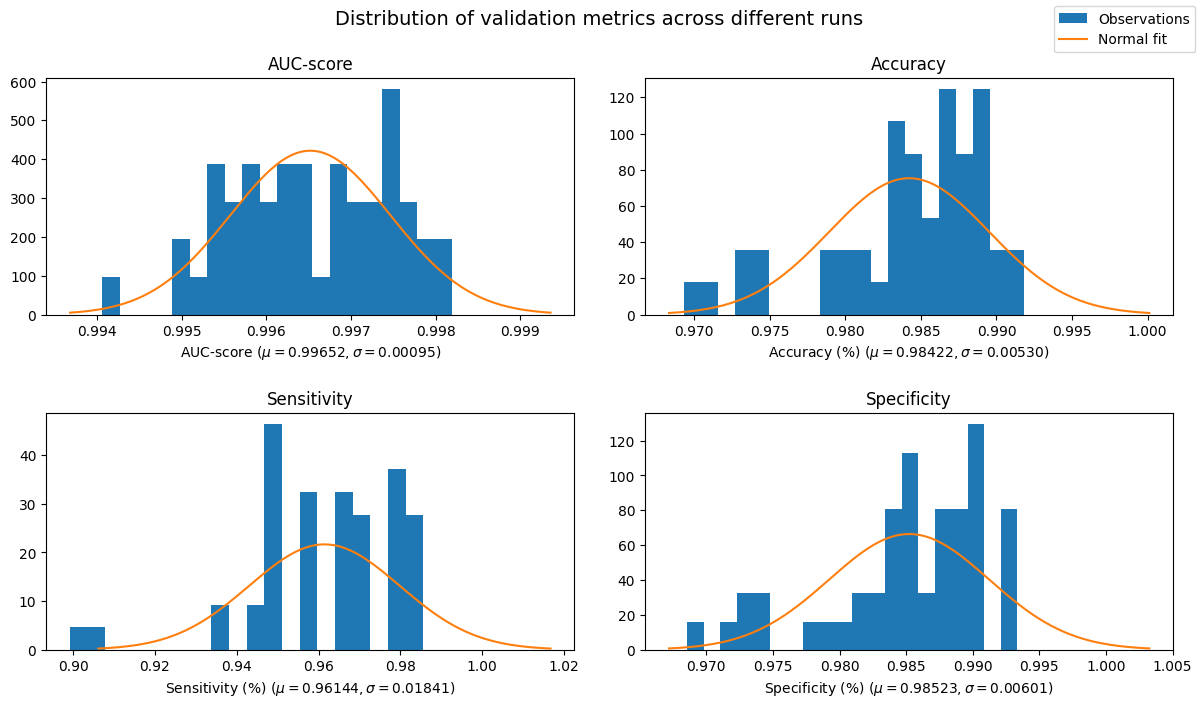

In [23]:
from matplotlib import pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import norm

result_df = pd.read_csv('rerunning_training.csv')

AUCs = result_df['auc']
accuracy = result_df['accuracy']
spec = result_df['specificity']
sens = result_df['sensitivity']

plt.figure()
fig, ((ax1, ax2),(ax3,ax4)) = plt.subplots(2, 2, figsize=(12, 7))
fig.suptitle('Distribution of validation metrics across different runs', fontsize=14, y=1.02)

plt.tight_layout(rect=[0, 0.05, 1, 1], h_pad=5.0, w_pad=2.0)
ax1.hist(result_df['auc'],bins=20,density=True,label='Observations')
mu = np.mean(AUCs)
std = np.std(AUCs)
x = np.linspace(mu-3*std,mu+3*std,300)
y = norm.pdf(x,mu,std)
ax1.set_title('AUC-score')
ax1.plot(x,y,label='Normal fit')
ax1.set_xlabel(
    f"AUC-score ($\\mu = {mu:.5f}, \\sigma= {std:.5f}$)"
)

ax2.hist(result_df['accuracy'],bins=20,density=True)
mu = np.mean(accuracy)
std = np.std(accuracy)
x = np.linspace(mu-3*std,mu+3*std,300)
y = norm.pdf(x,mu,std)
ax2.set_title('Accuracy')
ax2.set_xlabel(
    f"Accuracy (%) ($\\mu = {mu:.5f}, \\sigma= {std:.5f}$)"
)
ax2.plot(x,y)


ax3.hist(result_df['sensitivity'],bins=20,density=True)
mu = np.mean(sens)
std = np.std(sens)
x = np.linspace(mu-3*std,mu+3*std,300)
y = norm.pdf(x,mu,std)
ax3.set_title('Sensitivity')
ax3.set_xlabel(
    f"Sensitivity (%) ($\\mu = {mu:.5f}, \\sigma= {std:.5f}$)"
)
ax3.plot(x,y)

ax4.hist(result_df['specificity'],bins=20,density=True)
mu = np.mean(spec)
std = np.std(spec)
x = np.linspace(mu-3*std,mu+3*std,300)
y = norm.pdf(x,mu,std)
ax4.plot(x,y)
ax4.set_title('Specificity')
ax4.set_xlabel(
    f"Specificity (%) ($\\mu = {mu:.5f}, \\sigma= {std:.5f}$)"
)
fig.legend()
plt.show()

In [1]:
import pandas as pd

file_names= ['feed_forward_basic_kfold_metrics.csv','feed_forward_protein_kfold_metrics.csv','feed_forward_more_features_kfold_metrics.csv','feed_forward_more_features_larger_kfold_metrics.csv','cnn_base_case_kfold_metrics.csv','cnn_small_kernels_kfold_metrics.csv','cnn_large_kernels_kfold_metrics.csv',
             'cnn_no_global_pooling_kfold_metrics.csv','cnn_global_max_avg_std_pooling_kfold_metrics.csv','cnn_tiny_kfold_metrics.csv','cnn_small_kfold_metrics.csv','cnn_medium_kfold_metrics.csv','cnn_huge_kfold_metrics.csv','cnn_batchnorm_kfold_metrics.csv'
             ,'cnn_no_local_pooling_kfold_metrics.csv','cnn_batchnorm_and_local_pool_kfold_metrics.csv','cnn_shallow_kfold_metrics.csv','cnn_deep_kfold_metrics.csv','cnn_deeper_kfold_metrics.csv','cnn_deepest_kfold_metrics.csv','cnn_final_dilation_kfold_metrics.csv']

file_names = ['../models/' + a for a in file_names]
df = pd.DataFrame()

dfs = []

for filename in file_names:
    df = pd.read_csv(filename)
    df['val_auc'] = df['val_auc'] - df['val_auc'].mean()
    df['val_loss'] = df['val_loss'] - df['val_loss'].mean()
    df['val_sens'] = df['val_sens'] - df['val_sens'].mean()
    df['val_spec'] = df['val_spec'] - df['val_spec'].mean()
    df['val_accuracy'] = df['val_accuracy'] - df['val_accuracy'].mean()

    dfs.append(df)


df = pd.concat(dfs, ignore_index=True)

df

,fold,train_loss,val_loss,val_accuracy,val_auc,val_spec,val_sens,tn,fp,fn,tp
0,1,0.105723,-0.013339,0.561746,0.001296,0.008651,-0.015684,1830,55,44,225
1,2,0.130051,-0.029129,-0.181058,-0.005435,0.000163,-0.015684,1814,71,44,225
2,3,0.223159,0.003414,-0.134633,-0.023352,0.006529,-0.056576,1826,59,55,214
3,4,0.119964,-0.039473,1.211699,0.008061,0.012895,0.006621,1838,47,38,231
4,5,0.164329,-0.004756,0.840297,0.003158,0.014487,-0.034271,1841,44,49,220
...,...,...,...,...,...,...,...,...,...,...,...
205,6,0.064804,-0.032024,0.096913,0.001455,-0.002924,0.028202,1837,47,15,254
206,7,0.029015,0.035689,-0.644554,-0.004629,-0.003442,-0.027560,1837,48,30,239
207,8,0.102696,-0.009205,-2.408714,0.001642,-0.033150,0.039354,1781,104,12,257
208,9,0.017651,0.053291,0.840062,0.002138,0.011932,-0.016036,1864,19,27,243


<Figure size 640x480 with 0 Axes>

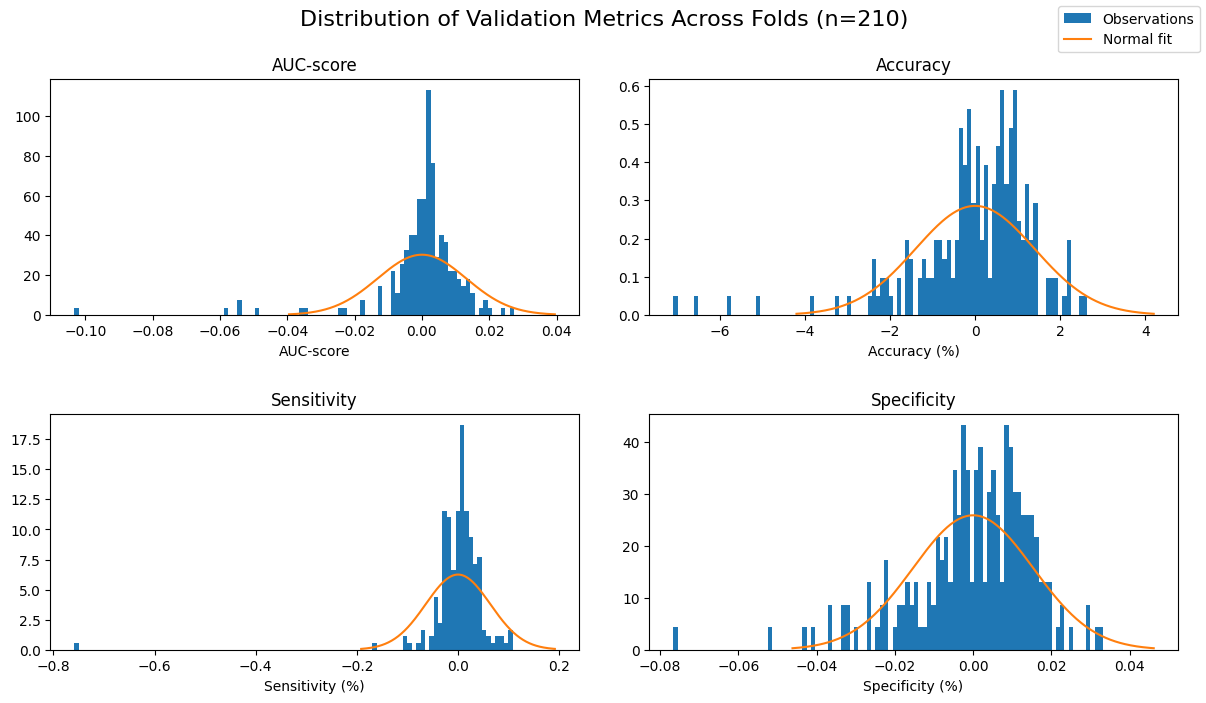

In [ ]:
import pandas as pd
from matplotlib import pyplot as plt
from scipy.stats import norm
import numpy as np

AUCs = df['val_auc']
accuracy = df['val_accuracy']
spec = df['val_spec']
sens = df['val_sens']

plt.figure()
fig, ((ax1, ax2),(ax3,ax4)) = plt.subplots(2, 2, figsize=(12, 7))
fig.suptitle('Distribution of Validation Metrics Across Folds (n=210)', fontsize=16, y=1.02)

plt.tight_layout(rect=[0, 0.05, 1, 1], h_pad=5.0, w_pad=2.0)
ax1.hist(df['val_auc'].sort_values(),bins=100,density=True,label='Observations')
mu = np.mean(AUCs)
std = np.std(AUCs)
x = np.linspace(mu-3*std,mu+3*std,300)
y = norm.pdf(x,mu,std)
ax1.set_title('AUC-score')
ax1.plot(x,y,label='Normal fit')
ax1.set_xlabel('AUC-score')

within = df[ (df['val_auc'] >= -3*std) & (df['val_auc'] <= 3*std)]
print(len(within))
print(len(df))
print(len(within)/len(df))

ax2.hist(df['val_accuracy'].sort_values(),bins=100,density=True)
mu = np.mean(accuracy)
std = np.std(accuracy)
x = np.linspace(mu-3*std,mu+3*std,300)
y = norm.pdf(x,mu,std)
ax2.set_title('Accuracy')
ax2.plot(x,y)
ax2.set_xlabel('Accuracy (%)')

ax3.hist(df['val_sens'].sort_values(),bins=100,density=True)
mu = np.mean(sens)
std = np.std(sens)
x = np.linspace(mu-3*std,mu+3*std,300)
y = norm.pdf(x,mu,std)
ax3.set_title('Sensitivity')
ax3.set_xlabel('Sensitivity (%)')
ax3.plot(x,y)

ax4.hist(df['val_spec'].sort_values(),bins=100,density=True)
mu = np.mean(spec)
std = np.std(spec)
x = np.linspace(mu-3*std,mu+3*std,300)
y = norm.pdf(x,mu,std)
ax4.plot(x,y)
ax4.set_title('Specificity')
ax4.set_xlabel('Specificity (%)')
fig.legend()
plt.show()



In [18]:
from functions.evaluation import generate_latex_table
import pandas as pd
df = pd.read_csv('../models/cnn_final_dilation_kfold_metrics.csv')
string = generate_latex_table(df)
print(string)


\begin{table}[H]
\begin{center}
\begin{minipage}{0.45\textwidth}
    \centering
    \begin{tabular}{cc|cc}
      \toprule
      & & \multicolumn{2}{c}{Predicted} \\
      & & Neg. & Pos. \\
      \midrule
      \multirow{2}{*}{\rotatebox[origin=c]{90}{Actual}}
      & Neg. & $94 \pm 59$ & $105 \pm 60$ \\[0.1em]
      & Pos. & $10 \pm 9$ & $308 \pm 9$ \\
      \addlinespace[0.6em]
      \bottomrule
    \end{tabular}
\end{minipage}%
\begin{minipage}{0.45\textwidth}
    \centering
    \begin{tabular}{lr}
      \toprule
      Accuracy    & $77.77 \pm 10.07$ \% \\
      AUC         & $0.9528 \pm 0.0131$ \\
      Sensitivity & $0.9697 \pm 0.0292$ \\
      Specificity & $0.4727 \pm 0.2976$ \\
      Avg. Val. loss & $0.1837 \pm 0.0766$ \\
      \bottomrule
    \end{tabular}
\end{minipage}
\end{center}
\caption{Caption}
\label{label}
\end{table}



In [1]:
from pathlib import Path
import pandas as pd

file_names = [
    'feed_forward_basic_kfold_metrics.csv',
    'feed_forward_protein_kfold_metrics.csv',
    'feed_forward_more_features_kfold_metrics.csv',
    'feed_forward_more_features_larger_kfold_metrics.csv',
    'cnn_base_case_kfold_metrics.csv',
    'cnn_small_kernels_kfold_metrics.csv',
    'cnn_large_kernels_kfold_metrics.csv',
    'cnn_no_global_pooling_kfold_metrics.csv',
    'cnn_global_max_avg_std_pooling_kfold_metrics.csv',
    'cnn_tiny_kfold_metrics.csv',
    'cnn_small_kfold_metrics.csv',
    'cnn_medium_kfold_metrics.csv',
    'cnn_huge_kfold_metrics.csv',
    'cnn_batchnorm_kfold_metrics.csv',
    'cnn_no_local_pooling_kfold_metrics.csv',
    'cnn_batchnorm_and_local_pool_kfold_metrics.csv',
    'cnn_shallow_kfold_metrics.csv',
    'cnn_deep_kfold_metrics.csv',
    'cnn_deeper_kfold_metrics.csv',
    'cnn_deepest_kfold_metrics.csv',
    'cnn_final_dilation_kfold_metrics.csv'
]

summary = []

for filename in file_names:
    df = pd.read_csv("../models/" + filename)

    model = Path(filename).stem.replace("_kfold_metrics", "")
    model = model.replace("_", " ")

    summary.append({
        "Model": model,
        "auc_mean": df["val_auc"].mean(),
        "auc_std": df["val_auc"].std(),

        "acc_mean": df["val_accuracy"].mean(),
        "acc_std": df["val_accuracy"].std(),

        "sens_mean": df["val_sens"].mean(),
        "sens_std": df["val_sens"].std(),

        "spec_mean": df["val_spec"].mean(),
        "spec_std": df["val_spec"].std(),
    })

summary_df = pd.DataFrame(summary)

summary_df = summary_df.sort_values(
    "auc_mean",
    ascending=False
).reset_index(drop=True)

print(summary_df.iloc[:,0].size)
for _, row in summary_df.iterrows():
    print(
        f"{row['Model']} & "
        f"${row['auc_mean']:.3f} \\pm {row['auc_std']:.3f}$ & "
        f"${row['acc_mean']:.2f} \\pm {row['acc_std']:.2f}$\\% & "
        f"${100*row['sens_mean']:.2f} \\pm {100*row['sens_std']:.2f}$\\% & "
        f"${100*row['spec_mean']:.2f} \\pm {100*row['spec_std']:.2f}$\\% \\\\"
    )

21
cnn deepest & $0.992 \pm 0.003$ & $97.01 \pm 1.01$\% & $94.28 \pm 2.03$\% & $97.40 \pm 1.32$\% \\
cnn deep & $0.992 \pm 0.003$ & $97.06 \pm 0.73$\% & $92.87 \pm 3.11$\% & $97.66 \pm 1.06$\% \\
cnn deeper & $0.992 \pm 0.002$ & $96.70 \pm 1.31$\% & $94.72 \pm 2.86$\% & $96.98 \pm 1.83$\% \\
cnn batchnorm & $0.991 \pm 0.004$ & $97.19 \pm 0.60$\% & $92.64 \pm 2.39$\% & $97.83 \pm 0.80$\% \\
cnn batchnorm and local pool & $0.989 \pm 0.003$ & $96.84 \pm 0.94$\% & $94.09 \pm 1.37$\% & $97.23 \pm 1.16$\% \\
cnn final dilation & $0.987 \pm 0.005$ & $97.02 \pm 1.01$\% & $91.60 \pm 3.01$\% & $97.80 \pm 1.38$\% \\
cnn medium & $0.987 \pm 0.006$ & $96.42 \pm 1.38$\% & $93.02 \pm 2.26$\% & $96.91 \pm 1.66$\% \\
cnn no global pooling & $0.986 \pm 0.005$ & $96.85 \pm 1.00$\% & $91.97 \pm 2.89$\% & $97.55 \pm 1.41$\% \\
cnn small & $0.986 \pm 0.007$ & $96.60 \pm 1.03$\% & $91.53 \pm 4.11$\% & $97.32 \pm 1.58$\% \\
cnn shallow & $0.985 \pm 0.006$ & $96.55 \pm 0.50$\% & $92.12 \pm 2.00$\% & $97.19 \pm